# 07 — Macro Regime Gate (Layer 7)

The gate decides *when* to trade, not *what*. Every signal in the ensemble
gets multiplied by the daily gate score, so the system sizes down
automatically in bad regimes.

**Rules-based, few knobs. Thresholds are market convention, not optimized.**

Signals:
- VIX (<25 ok, 25-35 caution, >35 risk-off)
- SPY vs 200dma (above ok, below caution, >10% below risk-off)
- Credit: HYG vs LQD relative return over 20 days
- Universe breadth: % of stocks above their own 200dma

In [1]:
import sys, sqlite3
sys.path.insert(0, '..')
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib.dates as mdates
import pandas as pd, numpy as np
sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline
from src.regime import compute_regime, regime_summary

In [2]:
# Compute the regime gate (~5s first time, pulls HYG/LQD from yfinance)
regime = compute_regime()
print(f"{len(regime):,} days | {regime.index[0].date()} -> {regime.index[-1].date()}")
summary = regime_summary(regime)
print(f"Risk-on: {summary['risk_on_pct']:.0f}%  |  "
      f"Caution: {summary['caution_pct']:.0f}%  |  "
      f"Risk-off: {summary['risk_off_pct']:.0f}%")
print(f"\nMultiplier value counts:\n{regime['multiplier'].value_counts().sort_index()}")

2,508 days | 2016-07-01 -> 2026-06-24
Risk-on: 64%  |  Caution: 22%  |  Risk-off: 15%

Multiplier value counts:
multiplier
0.25     371
0.60     542
1.00    1595
Name: count, dtype: int64


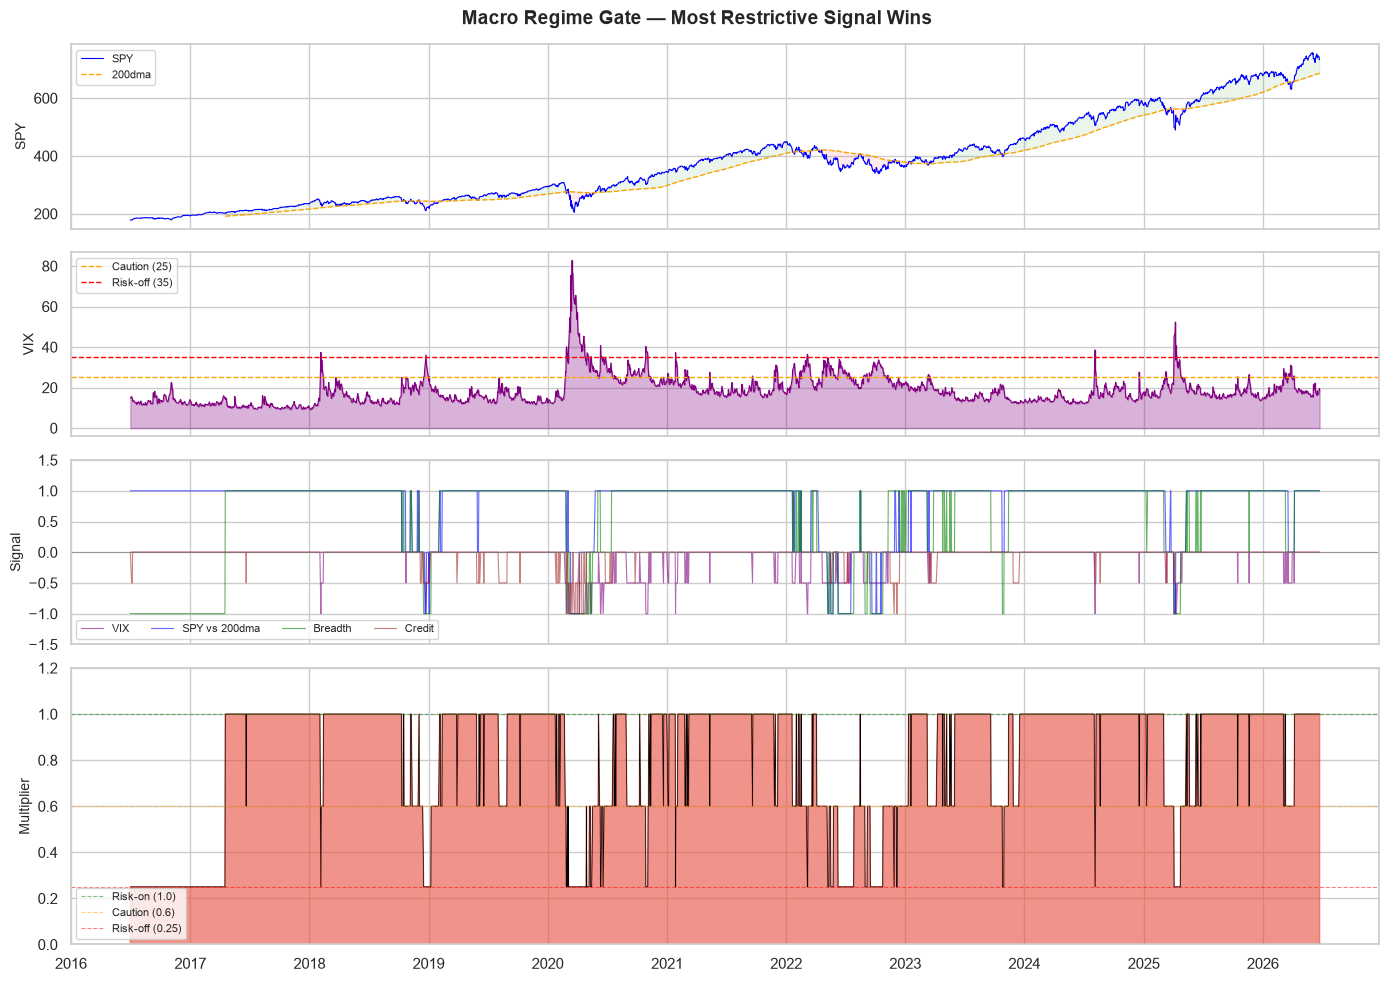

In [3]:
# Load SPY for the top panel
spy_px = pd.read_sql(
    "SELECT date, close FROM prices WHERE ticker='SPY' ORDER BY date",
    sqlite3.connect('../data/market.db'),
    parse_dates=['date'], index_col='date'
)['close']
spy_dma200 = spy_px.rolling(200, min_periods=200).mean()

# Plot: SPY, VIX, signals, multiplier
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True,
                          gridspec_kw={'height_ratios': [2, 2, 2, 3]})

# Panel 1: SPY with 200dma
axes[0].plot(spy_px.index, spy_px, color='blue', lw=0.8, label='SPY')
axes[0].plot(spy_dma200.index, spy_dma200, color='orange', lw=1, ls='--', label='200dma')
axes[0].fill_between(spy_px.index, spy_px, spy_dma200,
                     where=(spy_px >= spy_dma200), color='green', alpha=0.08)
axes[0].fill_between(spy_px.index, spy_px, spy_dma200,
                     where=(spy_px < spy_dma200), color='red', alpha=0.08)
axes[0].legend(fontsize=8, loc='upper left')
axes[0].set_ylabel('SPY', fontsize=10)

# Panel 2: VIX
if 'vix_close' in regime.columns:
    axes[1].fill_between(regime.index, 0, regime['vix_close'], alpha=0.3, color='purple')
    axes[1].plot(regime.index, regime['vix_close'], color='purple', lw=0.8)
    axes[1].axhline(25, color='orange', lw=1, ls='--', label='Caution (25)')
    axes[1].axhline(35, color='red', lw=1, ls='--', label='Risk-off (35)')
    axes[1].legend(fontsize=8, loc='upper left')
axes[1].set_ylabel('VIX', fontsize=10)

# Panel 3: Component signals
for col, color, label in [('vix_signal', 'purple', 'VIX'),
                           ('spy_signal', 'blue', 'SPY vs 200dma'),
                           ('breadth_signal', 'green', 'Breadth'),
                           ('credit_signal', 'brown', 'Credit')]:
    axes[2].plot(regime.index, regime[col], lw=0.8, color=color, alpha=0.6, label=label)
axes[2].legend(fontsize=8, loc='lower left', ncol=4)
axes[2].set_ylabel('Signal', fontsize=10)
axes[2].set_ylim(-1.5, 1.5)
axes[2].axhline(0, color='gray', lw=0.5)

# Panel 4: Multiplier (the output)
colors = np.where(regime['multiplier'] >= 0.95, '#2ecc71',
          np.where(regime['multiplier'] <= 0.30, '#e74c3c', '#f39c12'))
axes[3].fill_between(regime.index, 0, regime['multiplier'], color=colors, alpha=0.6)
axes[3].plot(regime.index, regime['multiplier'], color='black', lw=0.5)
axes[3].axhline(1.0, color='green', lw=0.8, ls='--', alpha=0.5, label='Risk-on (1.0)')
axes[3].axhline(0.6, color='orange', lw=0.8, ls='--', alpha=0.5, label='Caution (0.6)')
axes[3].axhline(0.25, color='red', lw=0.8, ls='--', alpha=0.5, label='Risk-off (0.25)')
axes[3].set_ylabel('Multiplier', fontsize=10)
axes[3].legend(fontsize=8, loc='lower left')
axes[3].set_ylim(0, 1.2)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
fig.suptitle('Macro Regime Gate — Most Restrictive Signal Wins', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# Key stress events — did the gate catch them?
events = [
    ('COVID crash', '2020-02-20', '2020-04-15'),
    ('2022 bear market', '2022-01-01', '2022-10-15'),
    ('2020 recovery', '2020-04-16', '2020-08-01'),
    ('2018 Q4 selloff', '2018-10-01', '2018-12-31'),
]

for label, start, end in events:
    mask = (regime.index >= start) & (regime.index <= end)
    sub = regime[mask]
    if len(sub) == 0:
        continue
    risk_on = (sub['multiplier'] >= 0.95).mean() * 100
    caution = ((sub['multiplier'] > 0.30) & (sub['multiplier'] < 0.95)).mean() * 100
    risk_off = (sub['multiplier'] <= 0.30).mean() * 100
    avg_mlt = sub['multiplier'].mean()
    avg_vix = sub['vix_close'].mean() if 'vix_close' in sub.columns else float('nan')
    print(f"{label:25s}  {len(sub):4d} days  "
          f"avg mult={avg_mlt:.2f}  VIX={avg_vix:.0f}  "
          f"risk-on={risk_on:.0f}% caution={caution:.0f}% risk-off={risk_off:.0f}%")

COVID crash                  39 days  avg mult=0.33  VIX=49  risk-on=5% caution=13% risk-off=82%
2022 bear market            198 days  avg mult=0.53  VIX=26  risk-on=14% caution=51% risk-off=35%
2020 recovery                75 days  avg mult=0.54  VIX=31  risk-on=11% caution=60% risk-off=29%
2018 Q4 selloff              63 days  avg mult=0.63  VIX=21  risk-on=22% caution=62% risk-off=16%


In [5]:
# How does regime correlate with forward returns?
# If the gate works, risk-off days should precede negative returns.
fwd_21d = spy_px.shift(-21) / spy_px - 1
fwd_63d = spy_px.shift(-63) / spy_px - 1
aligned = pd.DataFrame({
    'multiplier': regime['multiplier'],
    'spy_fwd_21d': fwd_21d,
    'spy_fwd_63d': fwd_63d,
}).dropna()

for regime_label, low, high in [('Risk-on', 0.95, 1.0), ('Caution', 0.31, 0.94), ('Risk-off', 0.0, 0.30)]:
    sub = aligned[(aligned['multiplier'] >= low) & (aligned['multiplier'] <= high)]
    if len(sub) == 0:
        continue
    print(f"{regime_label:10s}  {len(sub):5d} days  "
          f"fwd 21d: {sub['spy_fwd_21d'].mean()*100:+.2f}%  "
          f"fwd 63d: {sub['spy_fwd_63d'].mean()*100:+.2f}%")

Risk-on      1541 days  fwd 21d: +0.79%  fwd 63d: +2.55%
Caution       533 days  fwd 21d: +1.07%  fwd 63d: +5.29%
Risk-off      371 days  fwd 21d: +3.31%  fwd 63d: +6.89%
